<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
RandomForest ....
<a class="anchor" id="1"></a> 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import LearningCurveDisplay, train_test_split
from sklearn.ensemble import RandomForestClassifier

In [ ]:

# Load and display a sample of digits
digits = load_digits()
X, y = digits.data, digits.target

![](../../imgs/featureEngin.png)

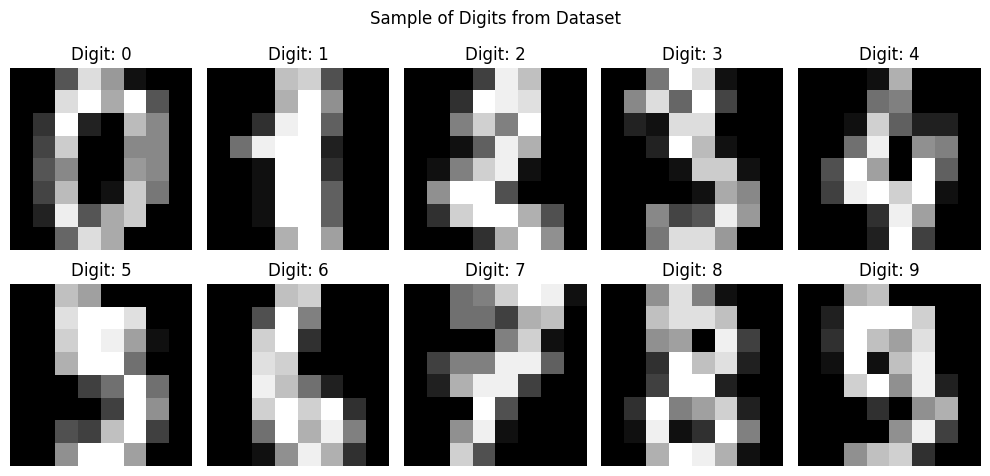

In [6]:
# Display 10 sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Digit: {digits.target[i]}")
    ax.axis('off')
plt.suptitle("Sample of Digits from Dataset")
plt.tight_layout()
plt.show()

![](../../imgs/dataSplit.jpg)

In [7]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 1437 samples
Testing set size: 360 samples


![](../../imgs/model.png)

In [8]:
# Define the model and display the learning curve
model = RandomForestClassifier(random_state=42)

In [9]:
common_params = {
    "X": X_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 10),
    "cv": 5,
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "Accuracy"
}

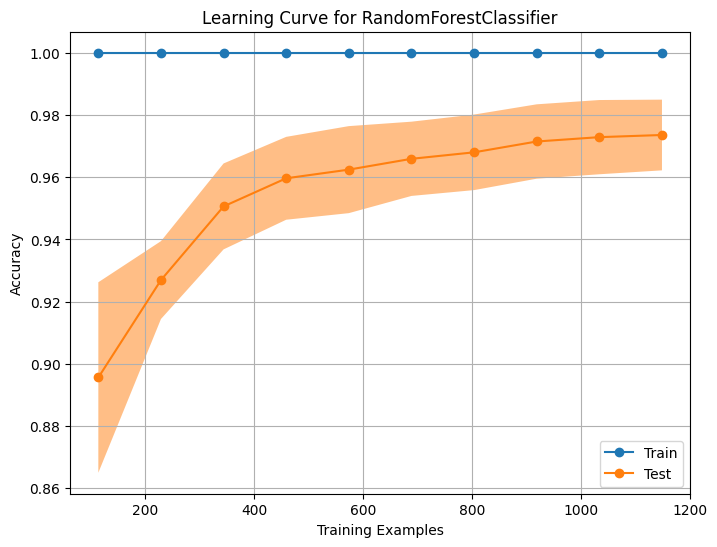

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
LearningCurveDisplay.from_estimator(model, **common_params, ax=ax)
ax.set_title("Learning Curve for RandomForestClassifier")
ax.set_xlabel("Training Examples")
ax.set_ylabel("Accuracy")
plt.grid(True)
plt.show()

In [11]:
# Train the model on the training set
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

![](../../imgs/metrics.png)

In [12]:
#Display "residuals" (prediction errors)
# For classification, residuals are not standard; we'll show correct vs incorrect predictions
correct = y_test == y_pred
incorrect_indices = np.where(~correct)[0]

print("\nSample of Incorrect Predictions:")
for i in range(min(5, len(incorrect_indices))):
    idx = incorrect_indices[i]
    print(f"Test sample {idx}: True label = {y_test[idx]}, Predicted = {y_pred[idx]}")



Sample of Incorrect Predictions:
Test sample 97: True label = 0, Predicted = 4
Test sample 133: True label = 7, Predicted = 9
Test sample 149: True label = 3, Predicted = 5
Test sample 159: True label = 9, Predicted = 7
Test sample 166: True label = 3, Predicted = 8


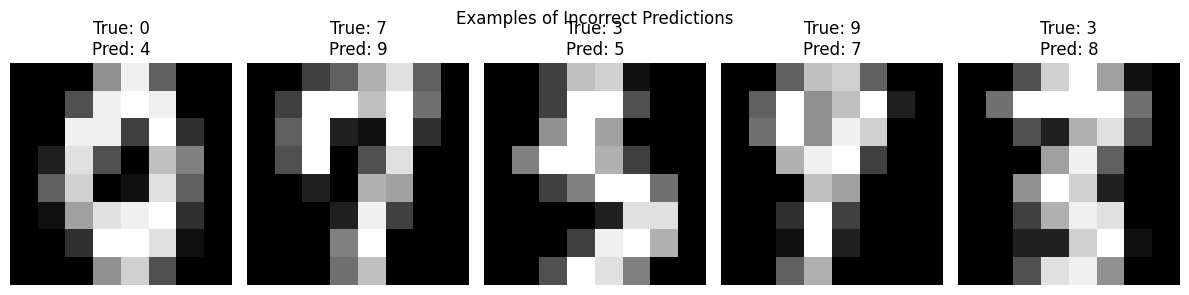

In [13]:
# Visualize a few incorrect predictions
fig, axes = plt.subplots(1, min(5, len(incorrect_indices)), figsize=(12, 3))
for i, ax in enumerate(axes):
    idx = incorrect_indices[i]
    ax.imshow(X_test[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
    ax.axis('off')
plt.suptitle("Examples of Incorrect Predictions")
plt.tight_layout()
plt.show()

In [15]:
#Display metrics
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("\nClassification Metrics:")
print(classification_report(y_test, y_pred))


Classification Metrics:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       1.00      0.94      0.97        34
           4       0.98      1.00      0.99        46
           5       0.94      0.96      0.95        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



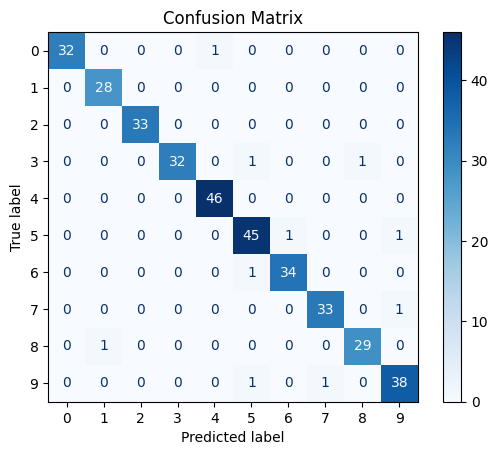

In [16]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()